# EDA — Análise de Notas Fiscais × Estoque (Polen)

**Pipeline:** Carga → Limpeza → EDA → Clusterização NATOP → Clusterização Produtos (Estoque → Invoices via TF-IDF) → Visualizações → Cobertura (36 meses) → Sazonalidade

**Dados:**
- `products_invoices.csv` — notas fiscais de compra/venda de materiais recicláveis
- `consulta_estoque.csv` — catálogo de produtos do estoque (fonte de verdade para grupos de material)

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load CSVs
df_invoices = pd.read_csv("products_invoices.csv")
df_estoque = pd.read_csv("consulta_estoque.csv")

print(f"products_invoices: {df_invoices.shape}")
print(f"consulta_estoque:  {df_estoque.shape}")

/var/folders/mq/jmjwxty97tjbkgg_0tjt9fm80000gn/T/ipykernel_31458/1850171837.py:11: DtypeWarning: Columns (87,89,91,92,95) have mixed types. Specify dtype option on import or set low_memory=False.
  df_invoices = pd.read_csv("products_invoices.csv")


products_invoices: (95320, 111)
consulta_estoque:  (66, 17)


In [32]:
df_estoque.head(60)


,instance_id,c_cod_int,c_codigo,c_descricao,codigo_local_estoque,estoque_minimo,fisico,n_cmc,n_cod_prod,n_pendente,n_preco_unitario,n_saldo,reservado,_fivetran_synced,_fivetran_deleted,_fivetran_batch,_fivetran_index
0,hive_cwb,NaN,PRD00019,PE PRETO / COLORIDO,3279359419,0.0,-17795.00,1.724247,3395614249,0.0,0.00,-17795.00,0.0,2026-02-26 00:50:40.525000+00:00,False,NaN,NaN
1,hive_cwb,NaN,PRD00010,PE CANELA,3279359419,0.0,-10578.00,1.692822,3395601729,0.0,1.80,-10578.00,0.0,2026-02-26 00:50:40.525000+00:00,False,NaN,NaN
2,hive_cwb,NaN,PRD00011,BORRA INDUSTRIAL,3279359419,0.0,8800.00,0.400000,3379924623,0.0,0.40,8800.00,0.0,2026-02-26 00:50:40.525000+00:00,False,NaN,NaN
3,hive_cwb,NaN,000001,SUCATA DE FILME COLORIDO,3279359419,0.0,14680.00,1.208076,3281136366,0.0,0.00,14680.00,0.0,2026-02-26 00:50:40.525000+00:00,False,NaN,NaN
4,hive_cwb,NaN,PRD00003,SUCATA DE PP BALDE BACIA COLORIDO,3279359419,0.0,-2450.00,2.200000,3281136438,0.0,0.00,-2450.00,0.0,2026-02-26 00:50:40.525000+00:00,False,NaN,NaN
5,hive_cwb,NaN,PRD00004,SUCATA DE PEAD CRISTAL,3279359419,0.0,9324.00,1.750622,3281136397,0.0,0.00,9324.00,0.0,2026-02-26 00:50:40.525000+00:00,False,NaN,NaN
6,hive_cwb,NaN,PRD00022,PP RAFIA,3279359419,0.0,7824.00,0.559036,3395601721,0.0,0.35,7824.00,0.0,2026-02-26 00:50:40.525000+00:00,False,NaN,NaN
7,hive_cwb,NaN,000002,SUCATA DE FILME CANELA,3279359419,0.0,5183.00,1.633500,3281136361,5183.0,0.00,5183.00,0.0,2026-02-26 19:18:10.097000+00:00,False,NaN,NaN
8,hive_cwb,NaN,000025,SUCATA DE FILME PRETO,3279359419,0.0,6500.00,0.400000,3281136371,6500.0,0.00,6500.00,0.0,2026-02-26 19:18:10.097000+00:00,False,NaN,NaN
9,hive_cwb,NaN,000028,SUCATA DE PEAD COLORIDO,3279359419,0.0,838.00,2.178007,3281136402,0.0,0.00,838.00,0.0,2026-03-06 13:02:05.090000+00:00,False,NaN,NaN


## 1. Limpeza de Colunas & Preparação

Remoção de colunas irrelevantes (IDs Fivetran, endereços, metadados), colunas com >50% nulos, parsing de datas e filtro para o período de análise (2023–2025).

In [33]:
# === Drop unwanted columns + parse dates + filter to 2023–2025 ===

# --- consulta_estoque ---
est_drop_cols = ["_fivetran_synced", "_fivetran_deleted", "estoque_minimo", "reservado"]
est_null_cols = df_estoque.columns[df_estoque.isnull().mean() > 0.5].tolist()
df_estoque = df_estoque.drop(columns=list(set(est_drop_cols + est_null_cols)), errors="ignore")

# --- products_invoices ---
inv_drop_cols = [
    "id_product", "fivetran_deleted_product",
    "id_operatorinvoice", "fivetran_deleted_operatorinvoice",
    "id_subsidiary", "fivetran_deleted_subsidiary", "companyid",
    "status_product", "product_invalidations", "product_nf",
    "licensecetesb", "sefaz_valida",
    "has_invoice_credit", "id_invoicecredit", "createdat_invoicecredit",
    "was_purchased", "purchaseordersids", "purchaseorders_codes",
    "was_compensation", "compensations_ids",
    "createdat_product", "createdat_operatorinvoice", "createdat_subsidiary",
    "danfe", "danfe_materials", "aditional_cpl_operatorinvoice",
    "isblocked_operatorinvoice", "volume_attention", "volume_attention_por_data",
    "invoice_in_offer",
    "emitterlegaldoc", "emitterlegalname", "emitterfantasyname",
    "emitterneighborhood", "emitternumber", "emitterphone",
    "emitterstreet", "emitterzipcode",
    "receiverlegaldoc", "receiverlegalname",
    "receivernumber", "receiverphone", "receiverstreet", "receiverzipcode",
    "status_subsidiary", "phone_subsidiary", "email_subsidiary",
    "address1_subsidiary", "neighbourhood_subsidiary",
    "number_subsidiary", "legalname_subsidiary", "cnpj_subsidiary",
    "zip_subsidiary",
]
inv_null_cols = df_invoices.columns[df_invoices.isnull().mean() > 0.5].tolist()
df_invoices = df_invoices.drop(columns=list(set(inv_drop_cols + inv_null_cols)), errors="ignore")

# Parse dates and add time columns
df_invoices["emittedat_operatorinvoice"] = pd.to_datetime(
    df_invoices["emittedat_operatorinvoice"], errors="coerce"
)
df_invoices["year"] = df_invoices["emittedat_operatorinvoice"].dt.year
df_invoices["month"] = df_invoices["emittedat_operatorinvoice"].dt.month
df_invoices["year_month"] = df_invoices["emittedat_operatorinvoice"].dt.to_period("M")

# Filter to analysis period
df_invoices = df_invoices[df_invoices["year"].isin([2023, 2024, 2025])].copy()

print(f"products_invoices (2023–2025): {df_invoices.shape}")
print(f"  Columns: {list(df_invoices.columns)}")
print(f"\nconsulta_estoque: {df_estoque.shape}")
print(f"  Columns: {list(df_estoque.columns)}")
print(f"\nRows per year:")
display(df_invoices["year"].value_counts().sort_index())

/var/folders/mq/jmjwxty97tjbkgg_0tjt9fm80000gn/T/ipykernel_31458/2495277071.py:41: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_invoices["year_month"] = df_invoices["emittedat_operatorinvoice"].dt.to_period("M")


products_invoices (2023–2025): (87943, 33)
  Columns: ['cfop', 'commercialunit_product', 'description_product', 'material', 'ncm', 'quantitytraded_product', 'quantitytradedkg_product', 'totalprice_product', 'unitprice_product', 'unitpricekg_product', 'emittedat_operatorinvoice', 'emittercnae', 'emittercity', 'emitterstateuf', 'natop_operatorinvoice', 'price_operatorinvoice', 'receiverid', 'receivercity', 'receivercnae', 'receiverfantasyname', 'receiverneighborhood', 'receiverstateuf', 'status_operatorinvoice', 'validvolume_operatorinvoice', 'volume_operatorinvoice', 'volume_total_por_data', 'name_subsidiary', 'type_subsidiary', 'state_subsidiary', 'city_subsidiary', 'year', 'month', 'year_month']

consulta_estoque: (66, 10)
  Columns: ['instance_id', 'c_codigo', 'c_descricao', 'codigo_local_estoque', 'fisico', 'n_cmc', 'n_cod_prod', 'n_pendente', 'n_preco_unitario', 'n_saldo']

Rows per year:


year
2023    15189
2024    34854
2025    37900
Name: count, dtype: int64

In [34]:
# === Compact EDA: nulls, numeric summary, categorical summary ===

# --- Null analysis (only show columns with nulls) ---
def null_summary(df, name):
    info = pd.DataFrame({
        "dtype": df.dtypes,
        "nulls": df.isnull().sum(),
        "null_%": (df.isnull().mean() * 100).round(1),
    })
    print(f"=== {name} — Nulls ===")
    display(info[info["nulls"] > 0])

null_summary(df_invoices, "products_invoices")
null_summary(df_estoque, "consulta_estoque")

# --- Numeric summary ---
force_categorical = ["cfop", "ncm"]
inv_num = df_invoices.select_dtypes(include="number").drop(columns=force_categorical, errors="ignore")

records = []
for col in inv_num.columns:
    s = inv_num[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    outliers = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
    records.append({
        "column": col, "count": len(s),
        "mean": s.mean(), "median": s.median(), "std": s.std(),
        "Q1": q1, "Q3": q3, "skewness": s.skew(), "outliers": outliers,
    })
print("\n=== products_invoices — Numeric Summary ===")
display(pd.DataFrame(records).set_index("column"))

# --- Categorical summary ---
inv_cat = pd.concat([
    df_invoices.select_dtypes(exclude="number"),
    df_invoices[df_invoices.columns.intersection(force_categorical)]
], axis=1)

cat_records = []
for col in inv_cat.columns:
    s = inv_cat[col].dropna()
    vc = s.value_counts()
    cat_records.append({
        "column": col, "non_null": len(s), "unique": s.nunique(),
        "top_value": vc.index[0] if len(vc) > 0 else np.nan,
        "top_%": round(vc.iloc[0] / len(s) * 100, 1) if len(s) > 0 and len(vc) > 0 else 0,
    })
print("\n=== products_invoices — Categorical Summary ===")
display(pd.DataFrame(cat_records).set_index("column"))

=== products_invoices — Nulls ===


,dtype,nulls,null_%
material,object,688,0.8
quantitytradedkg_product,float64,1300,1.5
unitpricekg_product,float64,1300,1.5
receivercity,object,2647,3.0
receivercnae,object,2647,3.0
receiverfantasyname,object,41335,47.0
receiverneighborhood,object,2647,3.0
receiverstateuf,object,2647,3.0
volume_operatorinvoice,float64,688,0.8
volume_total_por_data,float64,105,0.1


=== consulta_estoque — Nulls ===


,dtype,nulls,null_%



=== products_invoices — Numeric Summary ===


,count,mean,median,std,Q1,Q3,skewness,outliers
column,,,,,,,,
quantitytraded_product,87943,4876.676985,1217.00,9.762101e+03,233.000,5543.1,9.197897,9153
quantitytradedkg_product,86643,11392.051443,1350.00,4.787248e+05,263.000,5970.0,131.715315,8568
totalprice_product,87943,8982.244993,1025.00,4.020847e+04,273.260,4656.0,23.026403,11909
unitprice_product,87943,64.992099,1.00,2.407089e+03,0.450,2.5,119.877999,10001
unitpricekg_product,86643,23.927090,1.00,1.090110e+03,0.436,2.4,105.197081,8688
price_operatorinvoice,87943,18366.861047,6190.08,6.931718e+04,2558.000,12800.0,12.715884,8451
validvolume_operatorinvoice,87943,9781.229327,5150.00,8.250047e+04,1824.500,10935.0,140.016526,6038
volume_operatorinvoice,87255,19407.579096,6432.00,4.947655e+05,2881.900,12920.0,120.704431,6142
volume_total_por_data,87838,78175.652909,14182.00,1.776974e+06,6662.850,34698.8,92.747129,10115



=== products_invoices — Categorical Summary ===


,non_null,unique,top_value,top_%
column,,,,
commercialunit_product,87943,31,KG,97.5
description_product,87943,6692,SUCATA DE PLASTICO,1.7
material,87255,5,Plastic,50.5
emittedat_operatorinvoice,87943,37884,2023-10-18 21:00:00+00:00,0.2
emittercnae,87943,39,94.30-8-00,22.3
emittercity,87943,262,CURITIBA,8.2
emitterstateuf,87943,27,SP,18.2
natop_operatorinvoice,87943,325,VENDA,14.7
receiverid,87943,1724,c53821c9-7d81-48f9-905d-e41ddfc2c6ed,3.7


## 2. Clusterização de Operações (NATOP)

Classificação das ~50 naturezas de operação distintas em **5 categorias**: VENDA, COMPRA, VENDA INTERESTADUAL, COMPRA INTERESTADUAL, OUTROS. Filtragem para manter apenas registros com material e descrição válidos (exclui OUTROS).

Before: 87943 → df_clean: 85691 rows
Removed: 2252 (2.6%)



natop_category
VENDA                  79934
VENDA INTERESTADUAL     3043
COMPRA                  2714
Name: count, dtype: int64


=== NATOP → Categoria ===


,natop_category,natop_operatorinvoice,count
7,COMPRA,COMPRA PARA COMERCIALIZACAO,1251
8,COMPRA,COMPRA PARA INDUSTRIALIZACAO,884
14,COMPRA,Devolução de compra para industrialização,165
0,COMPRA,1102-COMPRAS PARA COMERCIALIZACAO (DO ESTADO),143
5,COMPRA,COMPRA DE MERCADORIA,83
17,COMPRA,Entrada de Sucata,75
16,COMPRA,ENTRADA DE MERCADORIA,37
6,COMPRA,COMPRA DE PROD COOPERADO,16
18,COMPRA,compra de mercadoria,15
4,COMPRA,COMPRA DE MATERIAL,12


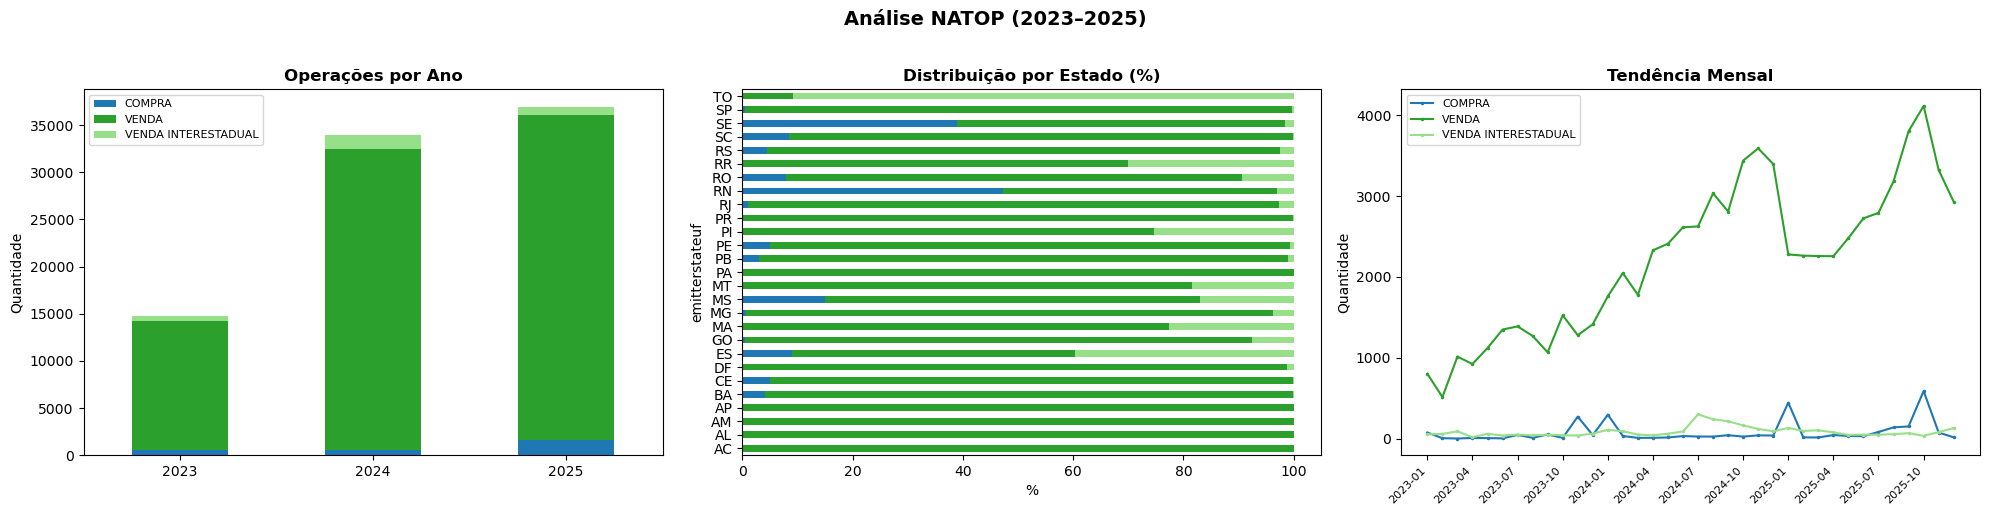

In [35]:
# === Classify NATOP into 5 categories + filter to df_clean ===

def classify_natop(natop):
    if pd.isna(natop):
        return "OUTROS"
    s = str(natop).strip().lower()
    is_inter = any(kw in s for kw in [
        "interestadual", "inter estadual", "interstate",
        "fora do estado", "fora estado", "outros estados",
    ])
    if is_inter:
        if any(kw in s for kw in ["venda", "vda", "saida", "saída", "remessa", "sucata"]):
            return "VENDA INTERESTADUAL"
        if any(kw in s for kw in ["compra", "cpa", "entrada", "aquisicao", "aquisição"]):
            return "COMPRA INTERESTADUAL"
        return "OUTROS"
    if any(kw in s for kw in ["venda", "vda", "vnd"]):
        return "VENDA"
    if re.search(r"\bsaida\b|\bsaída\b", s) and not any(kw in s for kw in ["devolucao", "devolução", "retorno"]):
        return "VENDA"
    if any(kw in s for kw in ["compra", "cpa"]):
        return "COMPRA"
    if re.search(r"\bentrada\b", s) and not any(kw in s for kw in ["devolucao", "devolução", "retorno"]):
        return "COMPRA"
    if any(kw in s for kw in ["aquisicao", "aquisição"]):
        return "COMPRA"
    return "OUTROS"

df_invoices["natop_category"] = df_invoices["natop_operatorinvoice"].apply(classify_natop)

# Filter: valid material + description + non-OUTROS → df_clean
mask = (
    df_invoices["material"].notna()
    & (df_invoices["material"].str.strip() != "")
    & (df_invoices["material"].str.strip().str.lower() != "unknown")
    & df_invoices["description_product"].notna()
    & (df_invoices["description_product"].str.strip() != "")
    & (df_invoices["natop_category"] != "OUTROS")
)
df_clean = df_invoices[mask].copy()

print(f"Before: {len(df_invoices)} → df_clean: {len(df_clean)} rows")
print(f"Removed: {len(df_invoices) - len(df_clean)} ({round((len(df_invoices)-len(df_clean))/len(df_invoices)*100,1)}%)\n")
display(df_clean["natop_category"].value_counts())

# --- NATOP → Category mapping table ---
mapping = (
    df_clean.groupby(["natop_category", "natop_operatorinvoice"])
    .size().reset_index(name="count")
    .sort_values(["natop_category", "count"], ascending=[True, False])
)
print("\n=== NATOP → Categoria ===")
pd.set_option("display.max_rows", None)
display(mapping)
pd.reset_option("display.max_rows")

# --- Charts ---
NATOP_COLORS = {
    "VENDA": "#2ca02c", "COMPRA": "#1f77b4",
    "VENDA INTERESTADUAL": "#98df8a", "COMPRA INTERESTADUAL": "#aec7e8",
}
cats_sorted = sorted(df_clean["natop_category"].unique())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Year
cat_year = df_clean.groupby(["year", "natop_category"]).size().reset_index(name="count")
cat_year_piv = cat_year.pivot(index="year", columns="natop_category", values="count").fillna(0)
cat_year_piv.plot(kind="bar", stacked=True, ax=axes[0],
                  color=[NATOP_COLORS.get(c, "#999") for c in cat_year_piv.columns])
axes[0].set_title("Operações por Ano", fontweight="bold")
axes[0].set_ylabel("Quantidade")
axes[0].set_xlabel("")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=0)

# 2) State %
cat_state = df_clean.groupby(["emitterstateuf", "natop_category"]).size().reset_index(name="count")
pct = cat_state.pivot(index="emitterstateuf", columns="natop_category", values="count").fillna(0)
pct = pct.div(pct.sum(axis=1), axis=0) * 100
pct.plot(kind="barh", stacked=True, ax=axes[1],
         color=[NATOP_COLORS.get(c, "#999") for c in pct.columns])
axes[1].set_title("Distribuição por Estado (%)", fontweight="bold")
axes[1].set_xlabel("%")
axes[1].legend().remove()

# 3) Monthly trend
cat_month = df_clean.groupby(["year_month", "natop_category"]).size().reset_index(name="count")
cat_month_piv = cat_month.pivot(index="year_month", columns="natop_category", values="count").fillna(0)
for col in cat_month_piv.columns:
    axes[2].plot(range(len(cat_month_piv)), cat_month_piv[col],
                 linewidth=1.5, marker=".", markersize=3, label=col,
                 color=NATOP_COLORS.get(col, "#999"))
axes[2].set_title("Tendência Mensal", fontweight="bold")
axes[2].set_ylabel("Quantidade")
tl = [str(t) for t in cat_month_piv.index]
axes[2].set_xticks(range(0, len(tl), 3))
axes[2].set_xticklabels(tl[::3], rotation=45, ha="right", fontsize=8)
axes[2].legend(fontsize=8)

plt.suptitle("Análise NATOP (2023–2025)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 3. Clusterização de Produtos

**Passo A:** Classificar os produtos do estoque (`c_descricao`) em famílias de material (PET, PP, PEAD, PS, PE/FILME, PVC, BOPP/RAFIA, OUTROS). Esta é a **fonte de verdade** para os grupos de material.

**Passo B:** Mapear as descrições das notas fiscais (`description_product`) para os produtos do estoque via TF-IDF + similaridade de cosseno. Cada nota herda o `material_group` do produto correspondente no estoque. Para notas sem match, usa-se a coluna `material` da própria nota como fallback.

In [36]:
# === Step A: Classify estoque products into material families ===
# The estoque c_descricao is the SOURCE OF TRUTH for material groups.
# All charts will use these groups and their colors.

def classify_material_group(text):
    """Classify a product description into a material family."""
    if pd.isna(text):
        return "OUTROS"
    s = str(text).strip().upper()
    # Order matters: PEAD before PE, BOPP before PP
    if "PEAD" in s:                              return "PEAD"
    if "PET" in s:                               return "PET"
    if "BOPP" in s or "RAFIA" in s:              return "BOPP/RAFIA"
    if "PP" in s:                                return "PP"
    if "PS" in s:                                return "PS"
    if "PVC" in s:                               return "PVC"
    if "PE " in s or "FILME" in s or s.startswith("PE"): return "PE/FILME"
    return "OUTROS"

# Apply to estoque
df_estoque["material_group"] = df_estoque["c_descricao"].apply(classify_material_group)

# Fixed color palette
GROUP_COLORS = {
    "PET":        "#1f77b4",  # blue
    "PP":         "#ff7f0e",  # orange
    "PEAD":       "#2ca02c",  # green
    "PS":         "#d62728",  # red
    "PE/FILME":   "#9467bd",  # purple
    "PVC":        "#8c564b",  # brown
    "BOPP/RAFIA": "#e377c2",  # pink
    "OUTROS":     "#7f7f7f",  # gray
}

# Show mapping table
estoque_groups = (
    df_estoque.groupby(["material_group", "c_descricao"])
    .size().reset_index(name="rows")
    .sort_values(["material_group", "rows"], ascending=[True, False])
)
print("=== Estoque: c_descricao → Material Group ===")
pd.set_option("display.max_rows", None)
display(estoque_groups)
pd.reset_option("display.max_rows")

print(f"\n=== Totals by group ===")
display(df_estoque["material_group"].value_counts().sort_index())

=== Estoque: c_descricao → Material Group ===


,material_group,c_descricao,rows
0,BOPP/RAFIA,PP RAFIA,2
1,BOPP/RAFIA,SUCATA DE BOPP,1
2,BOPP/RAFIA,Sucata de Rafia,1
3,OUTROS,BORRA INDUSTRIAL,1
4,OUTROS,PLÁSTICOS DIVERSOS,1
5,OUTROS,SUCATA DE AEROSOL,1
6,OUTROS,SUCATA DE BALDE BACIA PRETO,1
7,OUTROS,SUCATA DE LATINHAS,1
8,OUTROS,SUCATA DE PLASTICO,1
9,PE/FILME,PE CANELA,2



=== Totals by group ===


material_group
BOPP/RAFIA     4
OUTROS         6
PE/FILME      10
PEAD          10
PET           15
PP            17
PS             3
PVC            1
Name: count, dtype: int64

In [37]:
# === Step B: Map invoice descriptions → estoque products via TF-IDF ===
# Enhanced: synonym expansion + hybrid scoring (char n-gram + word-level).
# Each invoice inherits material_group from its matched estoque product.
# Fallback: classify directly from the invoice's material column.

def normalize_text(s):
    if pd.isna(s):
        return ""
    s = str(s).strip().upper()
    s = unicodedata.normalize("NFD", s)
    s = "".join(c for c in s if unicodedata.category(c) != "Mn")
    return " ".join(s.split())

# ── Synonym / alias expansion ──────────────────────────────────────────
# Replaces common invoice-side variants with canonical estoque tokens.
# Longest phrases are matched first (sorted by length desc).
SYNONYMS = {
    # Aluminum cans  →  estoque uses "LATINHAS"
    "LATAS DE ALUMINIO":     "LATINHAS",
    "LATA DE ALUMINIO":      "LATINHAS",
    "LATINHAS DE ALUMINIO":  "LATINHAS",
    "LATINHA DE ALUMINIO":   "LATINHAS",
    "LATA ALUMINIO":         "LATINHAS",
    "LATAS ALUMINIO":        "LATINHAS",
    "ALUMINIO LATA":         "LATINHAS",
    "LATINHA":               "LATINHAS",
    # Bags / sacolinha
    "SACOLAS":   "SACOLINHA",
    "SACOLA":    "SACOLINHA",
    "SACOLINHAS":"SACOLINHA",
    # Film / PE
    "FILME PEBD": "FILME",
    "FILME PE":   "FILME",
    "PEBD":       "PE",
    # Rafia / big-bag
    "RAFFIA":   "RAFIA",
    "BIG BAGS": "RAFIA",
    "BIG BAG":  "RAFIA",
    "BIGBAG":   "RAFIA",
    # Copa / cup
    "COPOS": "COPINHO",
    "COPO":  "COPINHO",
    # Margarine
    "POTES MARGARINA": "MARGARINA",
    "POTE MARGARINA":  "MARGARINA",
    "POTE DE MARGARINA": "MARGARINA",
    # Bucket / basin
    "BALDES": "BALDE BACIA",
    "BALDE":  "BALDE BACIA",
    "BACIAS": "BALDE BACIA",
    "BACIA":  "BALDE BACIA",
    # Cap / tampinha
    "TAMPAS":    "TAMPINHA",
    "TAMPA":     "TAMPINHA",
    "TAMPINHAS": "TAMPINHA",
    # Preforma
    "PRE-FORMA": "PREFORMA",
    "PRE FORMA": "PREFORMA",
    # Tray
    "BANDEJAS": "BANDEJA",
    # Scrap synonyms
    "APARAS DE": "SUCATA DE",
    "APARA DE":  "SUCATA DE",
    "APARAS":    "SUCATA",
    "APARA":     "SUCATA",
    # Qualifiers removed (noise for matching)
    "POS CONSUMO":  "",
    "POS-CONSUMO":  "",
    "PRE CONSUMO":  "",
    "PRE-CONSUMO":  "",
    "RECICLADO":    "",
    "RECICLADA":    "",
    "TRITURADO":    "",
    "TRITURADA":    "",
    "MOIDO":        "",
    "MOIDA":        "",
}

# Sort longest-first so multi-word phrases match before sub-phrases
_SORTED_SYNS = sorted(SYNONYMS.items(), key=lambda x: -len(x[0]))

def expand_synonyms(text):
    """Replace known synonym phrases with canonical forms (word-boundary safe)."""
    for old, new in _SORTED_SYNS:
        text = re.sub(r'\b' + re.escape(old) + r'\b', new, text)
    return " ".join(text.split())

# ── Canonical estoque product list ──────────────────────────────────────
estoque_products = sorted(set(
    p for p in df_estoque["c_descricao"].dropna().apply(normalize_text).unique() if p
))
estoque_expanded = [expand_synonyms(p) for p in estoque_products]

# Estoque product → material_group lookup (keyed by RAW normalized name)
estoque_to_group = {}
for _, row in df_estoque.dropna(subset=["c_descricao"]).iterrows():
    key = normalize_text(row["c_descricao"])
    if key:
        estoque_to_group[key] = row["material_group"]

# ── Unique invoice descriptions ─────────────────────────────────────────
unique_descs = sorted(set(
    d for d in df_clean["description_product"].dropna().apply(normalize_text).unique() if d
))
descs_expanded = [expand_synonyms(d) for d in unique_descs]

print(f"Estoque products: {len(estoque_products)}")
print(f"Invoice descriptions: {len(unique_descs)}")

# ── Hybrid TF-IDF (char n-gram + word-level) ────────────────────────────
all_expanded = estoque_expanded + descs_expanded
n_est = len(estoque_expanded)

# 1) Character n-gram (precision on surface form)
vec_char = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))
tfidf_char = vec_char.fit_transform(all_expanded)
sim_char = cosine_similarity(tfidf_char[n_est:], tfidf_char[:n_est])

# 2) Word-level unigrams + bigrams (captures token-level semantics)
vec_word = TfidfVectorizer(analyzer="word", ngram_range=(1, 2))
tfidf_word = vec_word.fit_transform(all_expanded)
sim_word = cosine_similarity(tfidf_word[n_est:], tfidf_word[:n_est])

# Combined: 50/50 blend
sim_matrix = 0.5 * sim_char + 0.5 * sim_word

THRESHOLD = 0.25  # lowered — synonym expansion already closes big gaps
match_map = {}
for i, desc in enumerate(unique_descs):
    best_idx = sim_matrix[i].argmax()
    best_score = sim_matrix[i, best_idx]
    if best_score >= THRESHOLD:
        match_map[desc] = (estoque_products[best_idx], round(best_score, 3))
    else:
        match_map[desc] = ("SEM CORRESPONDENCIA", round(best_score, 3))

# ── Apply to df_clean ────────────────────────────────────────────────────
df_clean["desc_normalized"] = df_clean["description_product"].apply(normalize_text)
df_clean["estoque_product"] = df_clean["desc_normalized"].map(
    lambda d: match_map.get(d, ("SEM CORRESPONDENCIA", 0))[0]
)
df_clean["match_score"] = df_clean["desc_normalized"].map(
    lambda d: match_map.get(d, ("SEM CORRESPONDENCIA", 0))[1]
)

# material_group: inherit from estoque match
df_clean["material_group"] = df_clean["desc_normalized"].map(
    lambda d: estoque_to_group.get(match_map.get(d, ("", 0))[0], None)
)
# Fallback for unmatched: classify from invoice material column
mask_no_group = df_clean["material_group"].isna()
df_clean.loc[mask_no_group, "material_group"] = (
    df_clean.loc[mask_no_group, "material"].apply(classify_material_group)
)

# High-confidence matches → df_matched
df_matched = df_clean[df_clean["match_score"] > 0.6].copy()

# ── Results ──────────────────────────────────────────────────────────────
print(f"\n=== Match Results ===")
print(f"Total: {len(df_clean)} | Matched (>0.6): {len(df_matched)} ({round(len(df_matched)/len(df_clean)*100,1)}%)")

score_bins = [0, 0.3, 0.5, 0.7, 0.9, 1.01]
score_labels = ["<0.30", "0.30–0.50", "0.50–0.70", "0.70–0.90", "0.90–1.00"]
df_clean["score_bin"] = pd.cut(df_clean["match_score"], bins=score_bins, labels=score_labels, right=False)
display(df_clean["score_bin"].value_counts().sort_index())

print(f"\n=== Material Group distribution (df_matched) ===")
display(df_matched["material_group"].value_counts().sort_index())

# Sample low-confidence matches for review
print(f"\n=== Low matches (score ≤ 0.3) for review ===")
sample_low = pd.DataFrame(
    [(d, m[0], m[1], estoque_to_group.get(m[0], "?"))
     for d, m in match_map.items() if m[1] <= 0.3],
    columns=["invoice_desc", "estoque_match", "score", "group"]
).sort_values("score", ascending=False)
display(sample_low.head(30))

Estoque products: 59
Invoice descriptions: 5619

=== Match Results ===
Total: 85691 | Matched (>0.6): 21269 (24.8%)


score_bin
<0.30        40987
0.30–0.50    17323
0.50–0.70    11829
0.70–0.90     7786
0.90–1.00     7766
Name: count, dtype: int64


=== Material Group distribution (df_matched) ===


material_group
BOPP/RAFIA     465
OUTROS        5429
PE/FILME       392
PEAD          3894
PET           6678
PP            3692
PS             247
PVC            472
Name: count, dtype: int64


=== Low matches (score ≤ 0.3) for review ===


,invoice_desc,estoque_match,score,group
2777,SUCATA PLASTICO RESINA,SUCATA DE PLASTICO,0.300,OUTROS
2769,SUCATA PLASTICO POLISTILENO CRISTAL,PET CRISTAL,0.300,PET
2392,"SUCATA DE PLASTICO CIF, (TIPO BORA PET)",SUCATA DE PLASTICO,0.300,OUTROS
280,APARAS DE PAPEL 2,SUCATA DE PLASTICO,0.300,OUTROS
289,APARAS DE PAPEL BRANCO IV- POS CONSUMO,SUCATA DE PEAD BRANCO,0.300,PEAD
488,APARAS PP/BOPP COLORIDO METAL LIMPO,SUCATA DE BOPP,0.299,BOPP/RAFIA
2800,SUCATA PP BRANCP,PP BRANCO,0.299,PP
2801,SUCATA PP COLORIDA,SUCATA DE PET COLORIDO,0.299,PET
1574,SOLTO - SUCATA PLASTICA COLORIDO - POS CONSUMO,SUCATA DE PET COLORIDO,0.299,PET
2083,SUCATA DE LATA,SUCATA DE LATINHAS,0.299,OUTROS


### Revisão da Clusterização (Matching Quality)

Avaliação completa do pipeline de matching: distribuição de scores, exemplos de matches por faixa, cobertura por grupo de material, e lista de descrições sem correspondência adequada.

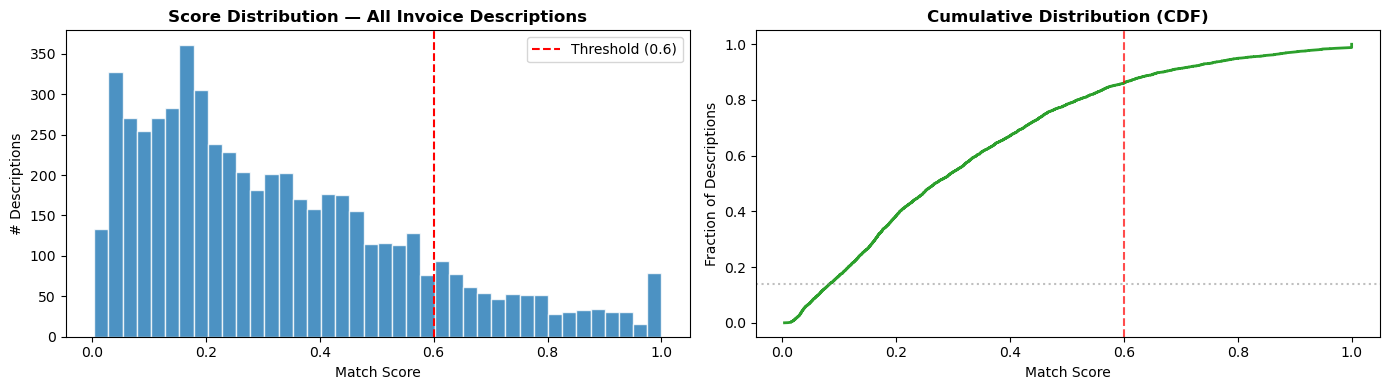

  MATCHING SUMMARY
  Unique invoice descriptions:  5,619
  High confidence (≥ 0.6):      787  (14.0%)
  Medium (0.3 – 0.6):           1,794  (31.9%)
  Low (< 0.3):                  3,038  (54.1%)
  Mean score:                    0.326
  Median score:                  0.268

  Row-level: 21,269 / 85,691 (24.8%) invoice rows matched (>0.6)

────────────────────────────────────────────────────────────
  ≥ 0.90 (excellent)  —  157 descriptions
    1.000  APARAS DE BALDE BACIA PRETO                        → SUCATA DE BALDE BACIA PRETO
    1.000  APARAS DE BALDE BACIA PRETO POS CONSUMO            → SUCATA DE BALDE BACIA PRETO
    1.000  APARAS DE PEAD BRANCO                              → SUCATA DE PEAD BRANCO
    1.000  APARAS DE PEAD COLORIDO                            → SUCATA DE PEAD COLORIDO
    1.000  APARAS DE PEAD COLORIDO POS CONSUMO                → SUCATA DE PEAD COLORIDO
    1.000  APARAS DE PLASTICO                                 → SUCATA DE PLASTICO
    1.000  APARAS DE PP BAL

In [38]:
# === Clusterization Review: comprehensive quality assessment ===

import textwrap

# ── 1. Score distribution histogram ─────────────────────────────────────
all_scores = [m[1] for m in match_map.values()]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(all_scores, bins=40, edgecolor="white", color="#1f77b4", alpha=0.8)
axes[0].axvline(0.6, color="red", linestyle="--", label="Threshold (0.6)")
axes[0].set_title("Score Distribution — All Invoice Descriptions", fontweight="bold")
axes[0].set_xlabel("Match Score")
axes[0].set_ylabel("# Descriptions")
axes[0].legend()

# CDF
sorted_scores = np.sort(all_scores)
axes[1].plot(sorted_scores, np.arange(1, len(sorted_scores)+1) / len(sorted_scores),
             color="#2ca02c", linewidth=2)
axes[1].axvline(0.6, color="red", linestyle="--", alpha=0.7)
axes[1].axhline(len([s for s in all_scores if s >= 0.6]) / len(all_scores),
                color="gray", linestyle=":", alpha=0.5)
axes[1].set_title("Cumulative Distribution (CDF)", fontweight="bold")
axes[1].set_xlabel("Match Score")
axes[1].set_ylabel("Fraction of Descriptions")
plt.tight_layout()
plt.show()

# ── 2. Summary statistics ───────────────────────────────────────────────
n_total = len(match_map)
n_above_06 = sum(1 for s in all_scores if s >= 0.6)
n_03_06 = sum(1 for s in all_scores if 0.3 <= s < 0.6)
n_below_03 = sum(1 for s in all_scores if s < 0.3)

print("=" * 60)
print(f"  MATCHING SUMMARY")
print("=" * 60)
print(f"  Unique invoice descriptions:  {n_total:,}")
print(f"  High confidence (≥ 0.6):      {n_above_06:,}  ({n_above_06/n_total*100:.1f}%)")
print(f"  Medium (0.3 – 0.6):           {n_03_06:,}  ({n_03_06/n_total*100:.1f}%)")
print(f"  Low (< 0.3):                  {n_below_03:,}  ({n_below_03/n_total*100:.1f}%)")
print(f"  Mean score:                    {np.mean(all_scores):.3f}")
print(f"  Median score:                  {np.median(all_scores):.3f}")
print("=" * 60)

# Row-level coverage
n_rows_total = len(df_clean)
n_rows_matched = len(df_matched)
print(f"\n  Row-level: {n_rows_matched:,} / {n_rows_total:,} "
      f"({n_rows_matched/n_rows_total*100:.1f}%) invoice rows matched (>0.6)")

# ── 3. Sample matches per score band ────────────────────────────────────
bands = [
    ("≥ 0.90 (excellent)", lambda s: s >= 0.90),
    ("0.70 – 0.90 (good)", lambda s: 0.70 <= s < 0.90),
    ("0.50 – 0.70 (fair)", lambda s: 0.50 <= s < 0.70),
    ("0.30 – 0.50 (weak)", lambda s: 0.30 <= s < 0.50),
    ("< 0.30 (poor/unmatched)", lambda s: s < 0.30),
]

for label, filt in bands:
    items = [(d, m[0], m[1]) for d, m in match_map.items() if filt(m[1])]
    n = len(items)
    print(f"\n{'─'*60}")
    print(f"  {label}  —  {n} descriptions")
    if n > 0:
        sample_items = sorted(items, key=lambda x: -x[2])[:8]
        for inv, est, sc in sample_items:
            print(f"    {sc:.3f}  {inv[:50]:<50s} → {est[:40]}")

# ── 4. Estoque product usage ────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  ESTOQUE PRODUCT COVERAGE")
print(f"{'='*60}")

used_products = set(m[0] for m in match_map.values() if m[0] != "SEM CORRESPONDENCIA")
unused_products = set(estoque_products) - used_products

print(f"  Estoque products used:   {len(used_products)} / {len(estoque_products)}")
print(f"  Estoque products unused: {len(unused_products)}")
if unused_products:
    print(f"  Unused: {sorted(unused_products)}")

# How many invoice descriptions map to each estoque product
product_counts = pd.Series([m[0] for m in match_map.values()]).value_counts()
print(f"\n  Top 15 most-matched estoque products:")
for prod, cnt in product_counts.head(15).items():
    grp = estoque_to_group.get(prod, "?")
    print(f"    {cnt:4d} descs  →  {prod:<45s} [{grp}]")

# ── 5. Synonym expansion impact (spot-check) ────────────────────────────
print(f"\n{'='*60}")
print(f"  SYNONYM EXPANSION SPOT-CHECK")
print(f"{'='*60}")

test_cases = [
    "SUCATA DE LATA DE ALUMINIO POS CONSUMO",
    "SUCATA DE LATA DE ALUMINIO",
    "SUCATA LATA ALUMINIO",
    "APARAS DE PET CRISTAL",
    "SACOLA PEAD",
    "FILME PE PRETO",
    "BIG BAG PP",
    "COPO PS",
    "POTE DE MARGARINA PP",
    "TAMPA PP COLORIDA",
]
for raw in test_cases:
    norm = normalize_text(raw)
    exp = expand_synonyms(norm)
    m = match_map.get(norm, None)
    if m:
        print(f"  {raw:<45s} → score={m[1]:.3f}  match={m[0]}")
    else:
        print(f"  {raw:<45s} → (not in invoice data)  expanded='{exp}'")

## 4. Análise por Grupo de Material

Visualizações agregadas por família de material: operações por ano, por estado, tendência mensal e drill-down de sub-produtos por grupo.

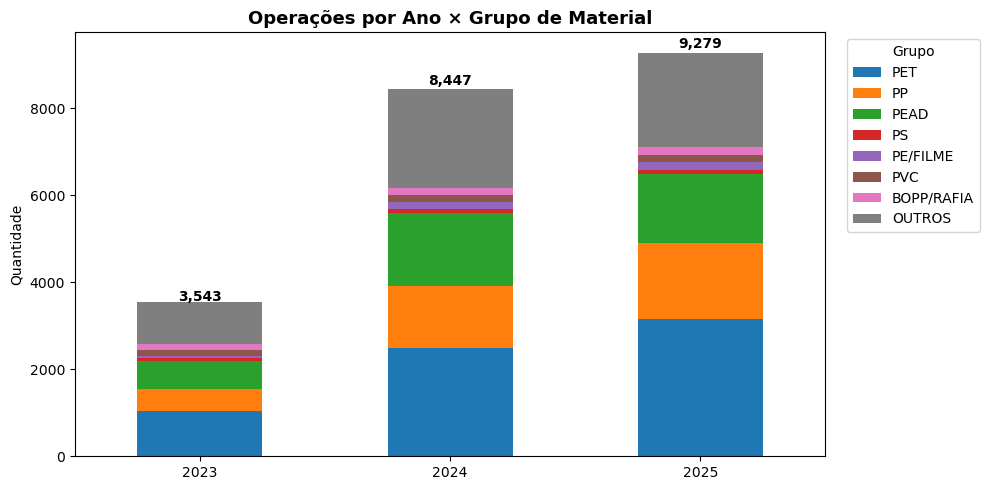

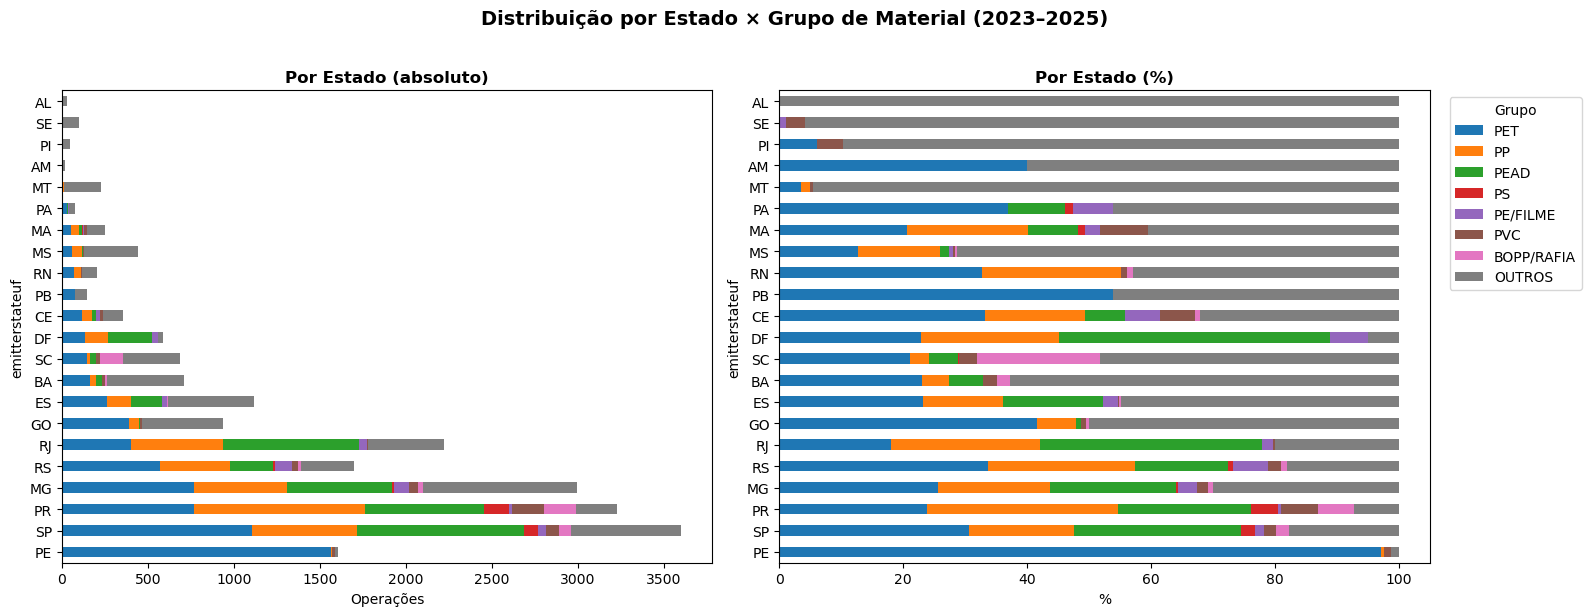

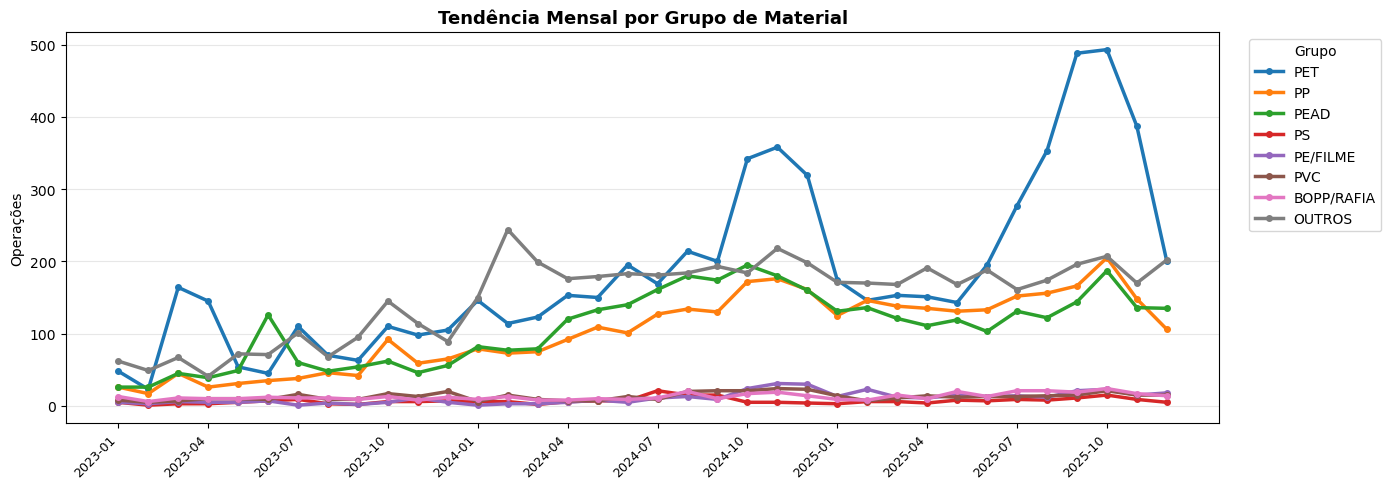

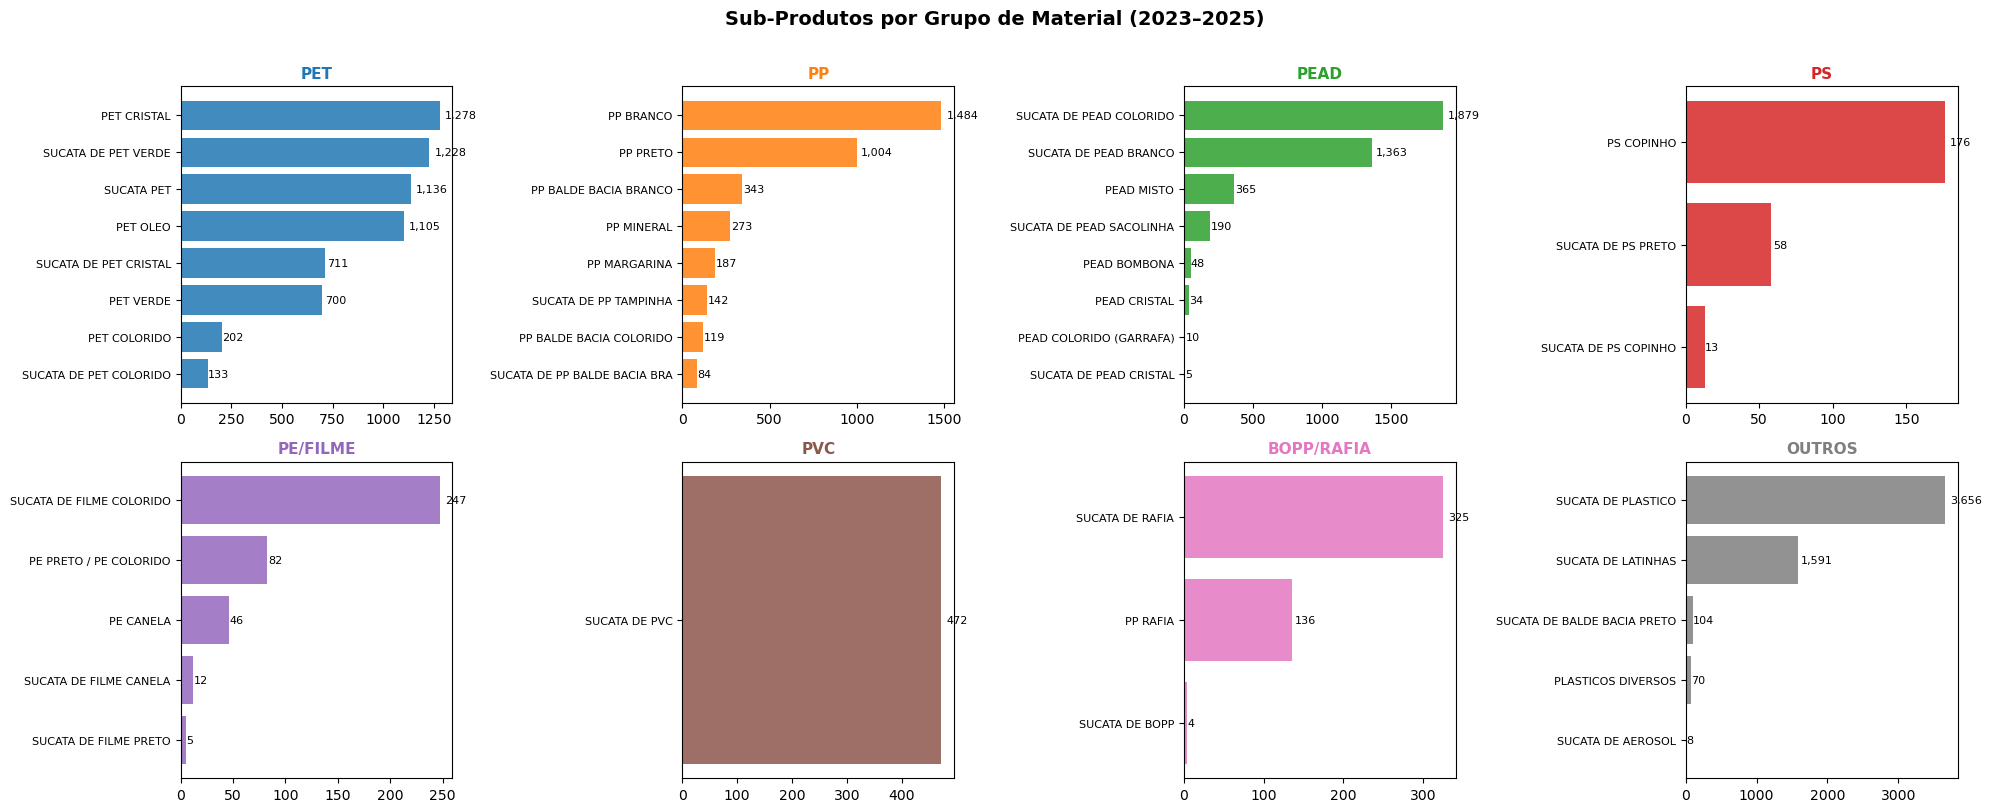

In [39]:
# === Visualizations by Material Group (2023–2025) ===

groups_sorted = [g for g in GROUP_COLORS if g in df_matched["material_group"].unique()]
venda_cats = ["VENDA", "VENDA INTERESTADUAL"]
compra_cats = ["COMPRA", "COMPRA INTERESTADUAL"]

# =============================================
# 1. Operations per year by material_group
# =============================================
grp_year = df_matched.groupby(["year", "material_group"]).size().reset_index(name="count")
grp_year_pivot = grp_year.pivot(index="year", columns="material_group", values="count").fillna(0).astype(int)
grp_year_pivot = grp_year_pivot[[g for g in groups_sorted if g in grp_year_pivot.columns]]

fig, ax = plt.subplots(figsize=(10, 5))
grp_year_pivot.plot(kind="bar", stacked=True, ax=ax,
                    color=[GROUP_COLORS[g] for g in grp_year_pivot.columns])
ax.set_title("Operações por Ano × Grupo de Material", fontsize=13, fontweight="bold")
ax.set_ylabel("Quantidade")
ax.set_xlabel("")
ax.legend(title="Grupo", bbox_to_anchor=(1.02, 1), loc="upper left")
for i, yr in enumerate(grp_year_pivot.index):
    total = grp_year_pivot.loc[yr].sum()
    ax.text(i, total + total * 0.01, f"{int(total):,}", ha="center", fontsize=10, fontweight="bold")
ax.set_xticklabels([str(int(y)) for y in grp_year_pivot.index], rotation=0)
plt.tight_layout()
plt.show()

# =============================================
# 2. Operations by State × Material Group
# =============================================
grp_state = df_matched.groupby(["emitterstateuf", "material_group"]).size().reset_index(name="count")
grp_state_pivot = grp_state.pivot(index="emitterstateuf", columns="material_group", values="count").fillna(0).astype(int)
grp_state_pivot = grp_state_pivot[[g for g in groups_sorted if g in grp_state_pivot.columns]]
grp_state_pivot = grp_state_pivot[grp_state_pivot.sum(axis=1) >= 10].sort_values(
    by=grp_state_pivot.columns.tolist(), ascending=False)
grp_state_pct = grp_state_pivot.div(grp_state_pivot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
grp_state_pivot.plot(kind="barh", stacked=True, ax=axes[0],
                     color=[GROUP_COLORS[g] for g in grp_state_pivot.columns])
axes[0].set_title("Por Estado (absoluto)", fontweight="bold")
axes[0].set_xlabel("Operações")
axes[0].legend().remove()

grp_state_pct.plot(kind="barh", stacked=True, ax=axes[1],
                   color=[GROUP_COLORS[g] for g in grp_state_pct.columns])
axes[1].set_title("Por Estado (%)", fontweight="bold")
axes[1].set_xlabel("%")
axes[1].legend(title="Grupo", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.suptitle("Distribuição por Estado × Grupo de Material (2023–2025)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# =============================================
# 3. Monthly trend by material_group
# =============================================
grp_month = df_matched.groupby(["year_month", "material_group"]).size().reset_index(name="count")
grp_month_pivot = grp_month.pivot(index="year_month", columns="material_group", values="count").fillna(0)
grp_month_pivot = grp_month_pivot[[g for g in groups_sorted if g in grp_month_pivot.columns]]

fig, ax = plt.subplots(figsize=(14, 5))
for col in grp_month_pivot.columns:
    ax.plot(range(len(grp_month_pivot)), grp_month_pivot[col],
            linewidth=2.5, marker="o", markersize=4, label=col, color=GROUP_COLORS[col])
ax.set_title("Tendência Mensal por Grupo de Material", fontsize=13, fontweight="bold")
ax.set_ylabel("Operações")
ax.legend(title="Grupo", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
tick_labels = [str(t) for t in grp_month_pivot.index]
ax.set_xticks(range(0, len(tick_labels), 3))
ax.set_xticklabels(tick_labels[::3], rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

# =============================================
# 4. Drill-down: sub-products per material_group
# =============================================
n_groups = len(groups_sorted)
ncols = min(4, n_groups)
nrows = (n_groups + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=False)
axes_flat = np.array(axes).flatten()

for idx, grp in enumerate(groups_sorted):
    ax = axes_flat[idx]
    grp_data = df_matched[df_matched["material_group"] == grp]
    sub_counts = grp_data["estoque_product"].value_counts().head(8)
    bars = ax.barh(range(len(sub_counts)), sub_counts.values, color=GROUP_COLORS[grp], alpha=0.85)
    ax.set_yticks(range(len(sub_counts)))
    ax.set_yticklabels([s[:28] for s in sub_counts.index], fontsize=8)
    ax.invert_yaxis()
    ax.set_title(grp, fontsize=11, fontweight="bold", color=GROUP_COLORS[grp])
    for bar, val in zip(bars, sub_counts.values):
        ax.text(bar.get_width() + bar.get_width() * 0.02, bar.get_y() + bar.get_height() / 2,
                f"{val:,}", va="center", fontsize=8)

for idx in range(len(groups_sorted), len(axes_flat)):
    axes_flat[idx].axis("off")

plt.suptitle("Sub-Produtos por Grupo de Material (2023–2025)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 5. Cobertura de Dados (Calendário Fixo: Jan 2023 – Dez 2025)

Análise de completude usando um calendário fixo de **36 meses** (Jan 2023 → Dez 2025). Para cada par (grupo de material × estado), calcula-se quantos dos 36 meses possuem dados de vendas ou compras.

Calendário fixo: 2023-01 → 2025-12 (36 meses)

Vendas: 20874 rows | Compras: 395 rows


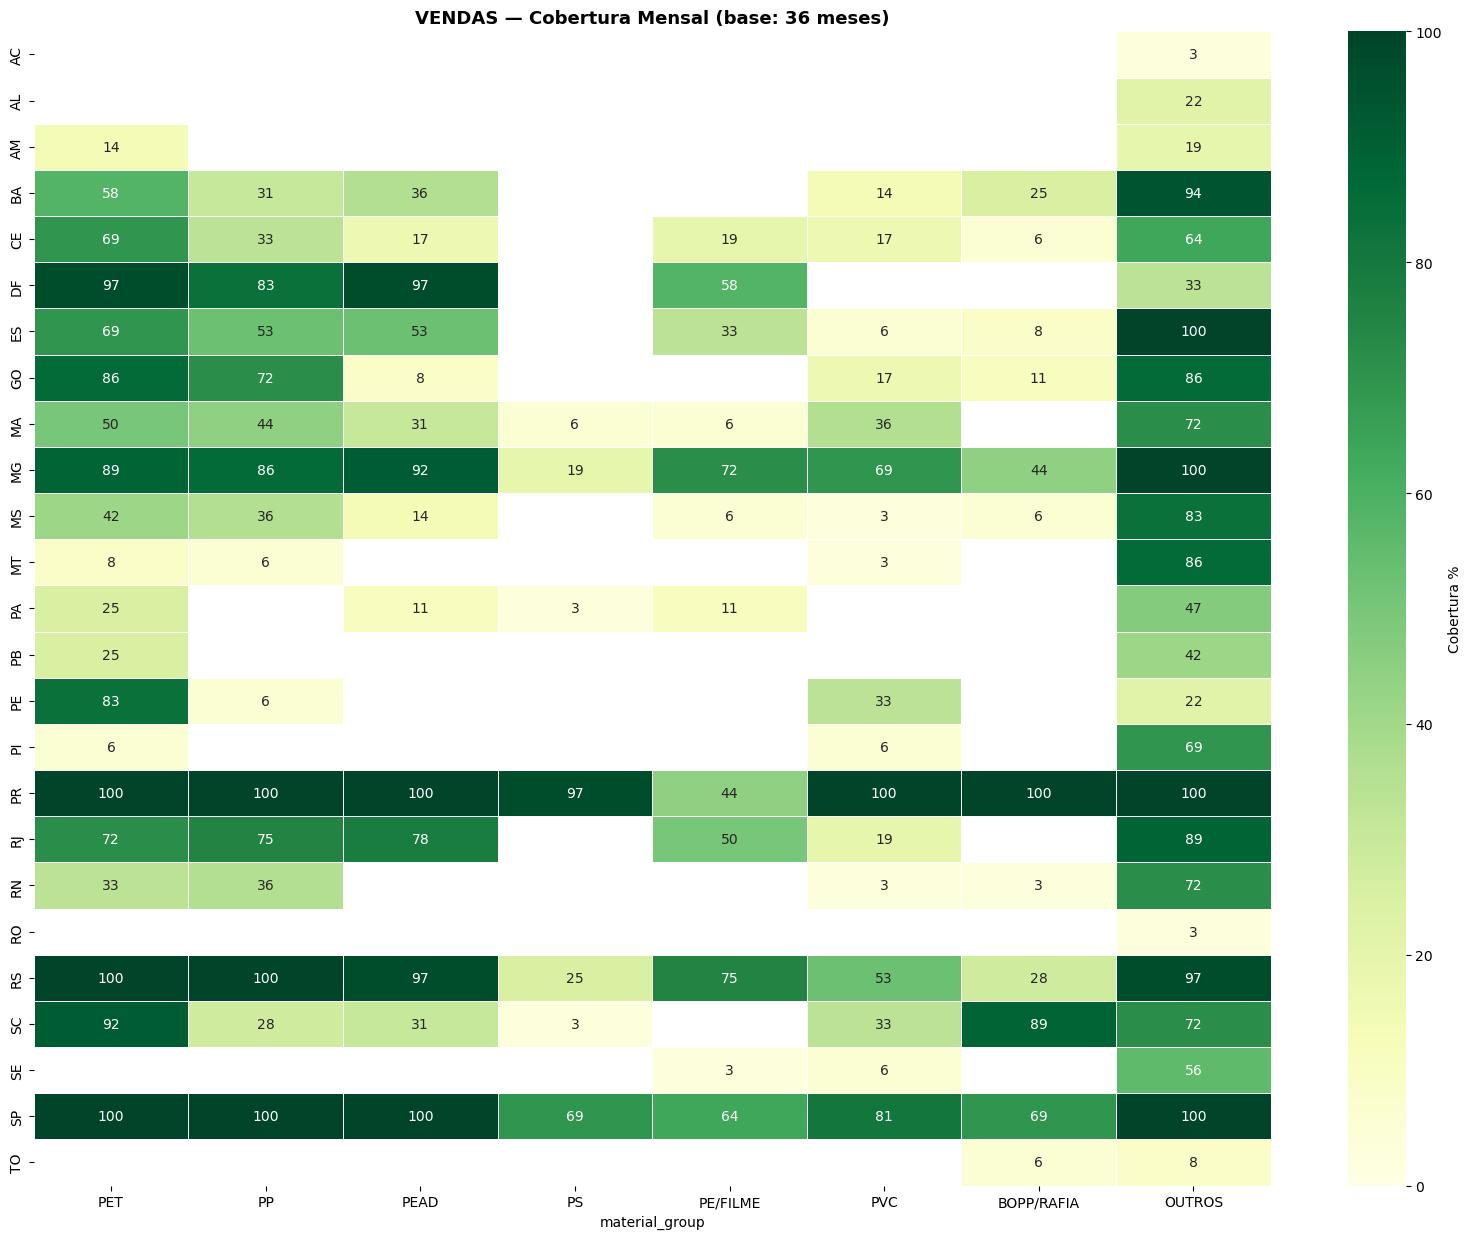

,material_group,state,months_with_data,total_months,coverage_%,total_ops
93,PP,PR,36,36,100.0,993
98,PP,SP,36,36,100.0,611
80,PET,RS,36,36,100.0,562
62,PEAD,SP,36,36,100.0,969
58,PEAD,PR,36,36,100.0,693
...,...,...,...,...,...,...
112,PVC,MS,1,36,2.8,1
113,PVC,MT,1,36,2.8,1
7,BOPP/RAFIA,RN,1,36,2.8,2
118,PVC,RN,1,36,2.8,2


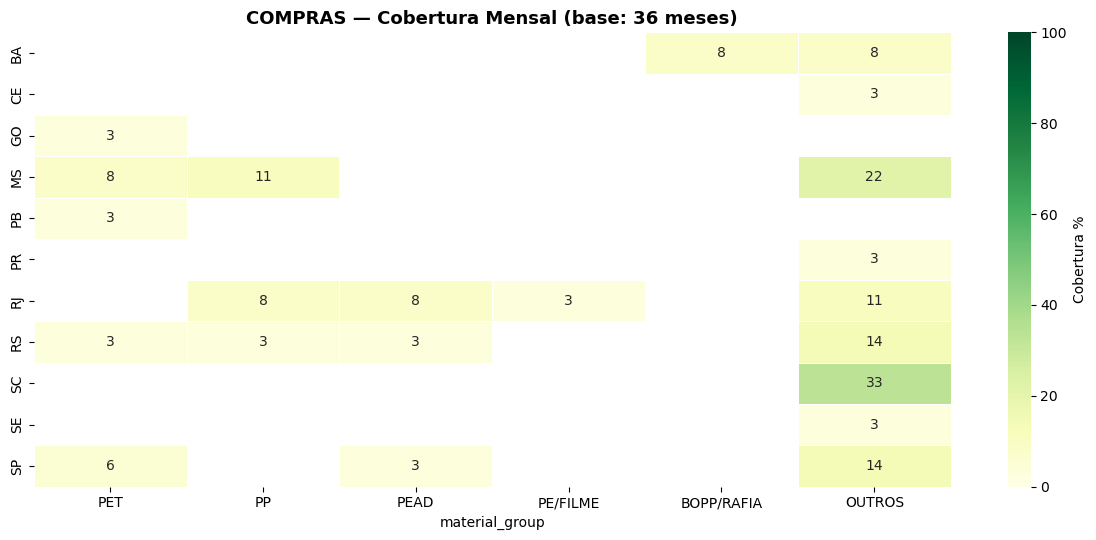

,material_group,state,months_with_data,total_months,coverage_%,total_ops
7,OUTROS,SC,12,36,33.3,143
3,OUTROS,MS,8,36,22.2,47
6,OUTROS,RS,5,36,13.9,15
9,OUTROS,SP,5,36,13.9,24
19,PP,MS,4,36,11.1,25
5,OUTROS,RJ,4,36,11.1,11
0,BOPP/RAFIA,BA,3,36,8.3,3
1,OUTROS,BA,3,36,8.3,6
20,PP,RJ,3,36,8.3,5
15,PET,MS,3,36,8.3,3



VENDAS: 58 pares com ≥ 50% cobertura (8 grupos, 18 estados)

COMPRAS: 0 pares com ≥ 50% cobertura (0 grupos, 0 estados)


In [40]:
# === Completeness analysis: fixed 36-month calendar (Jan 2023 – Dec 2025) ===

ALL_MONTHS = pd.period_range("2023-01", "2025-12", freq="M")
TOTAL_MONTHS = len(ALL_MONTHS)  # 36

print(f"Calendário fixo: {ALL_MONTHS[0]} → {ALL_MONTHS[-1]} ({TOTAL_MONTHS} meses)\n")

df_mg_vendas = df_matched[df_matched["natop_category"].isin(venda_cats)]
df_mg_compras = df_matched[df_matched["natop_category"].isin(compra_cats)]
print(f"Vendas: {len(df_mg_vendas)} rows | Compras: {len(df_mg_compras)} rows")

def group_completeness(df_subset, label):
    """Coverage per material_group × state against fixed 36-month calendar."""
    if len(df_subset) == 0:
        print(f"\n=== {label}: sem dados ===")
        return None

    grp_state_month = (
        df_subset.groupby(["material_group", "emitterstateuf", "year_month"])
        .size().reset_index(name="count")
    )
    pairs = (
        df_subset.groupby(["material_group", "emitterstateuf"])
        .size().reset_index()[["material_group", "emitterstateuf"]]
    )

    records = []
    for _, row in pairs.iterrows():
        grp, st = row["material_group"], row["emitterstateuf"]
        pair_data = grp_state_month[
            (grp_state_month["material_group"] == grp) & (grp_state_month["emitterstateuf"] == st)
        ]
        months_with_data = len(pair_data)
        records.append({
            "material_group": grp, "state": st,
            "months_with_data": months_with_data,
            "total_months": TOTAL_MONTHS,
            "coverage_%": round(months_with_data / TOTAL_MONTHS * 100, 1),
            "total_ops": pair_data["count"].sum(),
        })

    comp = pd.DataFrame(records).sort_values("coverage_%", ascending=False)

    # Heatmap
    cov_pivot = comp.pivot(index="state", columns="material_group", values="coverage_%")
    cov_pivot = cov_pivot[[g for g in groups_sorted if g in cov_pivot.columns]]

    fig, ax = plt.subplots(figsize=(max(8, len(cov_pivot.columns) * 2), max(4, len(cov_pivot) * 0.5)))
    sns.heatmap(cov_pivot, annot=True, fmt=".0f", cmap="YlGn", vmin=0, vmax=100,
                linewidths=0.5, ax=ax, cbar_kws={"label": "Cobertura %"}, annot_kws={"size": 10})
    ax.set_title(f"{label} — Cobertura Mensal (base: {TOTAL_MONTHS} meses)",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

    display(comp)
    return comp

comp_vendas = group_completeness(df_mg_vendas, "VENDAS")
comp_compras = group_completeness(df_mg_compras, "COMPRAS")

for label, comp in [("VENDAS", comp_vendas), ("COMPRAS", comp_compras)]:
    if comp is not None:
        good = comp[comp["coverage_%"] >= 50]
        print(f"\n{label}: {len(good)} pares com ≥ 50% cobertura "
              f"({good['material_group'].nunique()} grupos, {good['state'].nunique()} estados)")

## 6. Sazonalidade de Preços (R$/kg)

Análise de sazonalidade de preço unitário (R$/kg) por grupo de material, **todos os estados**. Só inclui combinações (grupo × estado) com pelo menos 1 linha por mês por sub-produto em média. Inclui heatmap de preço-referência (mediana R$/kg) ao final.

Rows with valid price: 21185

Data sufficiency (≥1 row/month/sub-product):


/var/folders/mq/jmjwxty97tjbkgg_0tjt9fm80000gn/T/ipykernel_31458/3352290291.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,material_group,emitterstateuf,n_rows,n_sub,avg_per_month_sub
5,BOPP/RAFIA,PR,185.0,2.0,2.569444
8,BOPP/RAFIA,SC,136.0,1.0,3.777778
14,OUTROS,BA,430.0,3.0,3.981481
15,OUTROS,CE,114.0,3.0,1.055556
17,OUTROS,ES,500.0,2.0,6.944444
18,OUTROS,GO,468.0,3.0,4.333333
20,OUTROS,MG,890.0,4.0,6.180556
21,OUTROS,MS,315.0,5.0,1.750000
22,OUTROS,MT,209.0,2.0,2.902778
24,OUTROS,PB,66.0,1.0,1.833333



Groups with ≥1 sufficient state: ['PET', 'PP', 'PEAD', 'PS', 'PE/FILME', 'PVC', 'BOPP/RAFIA', 'OUTROS']


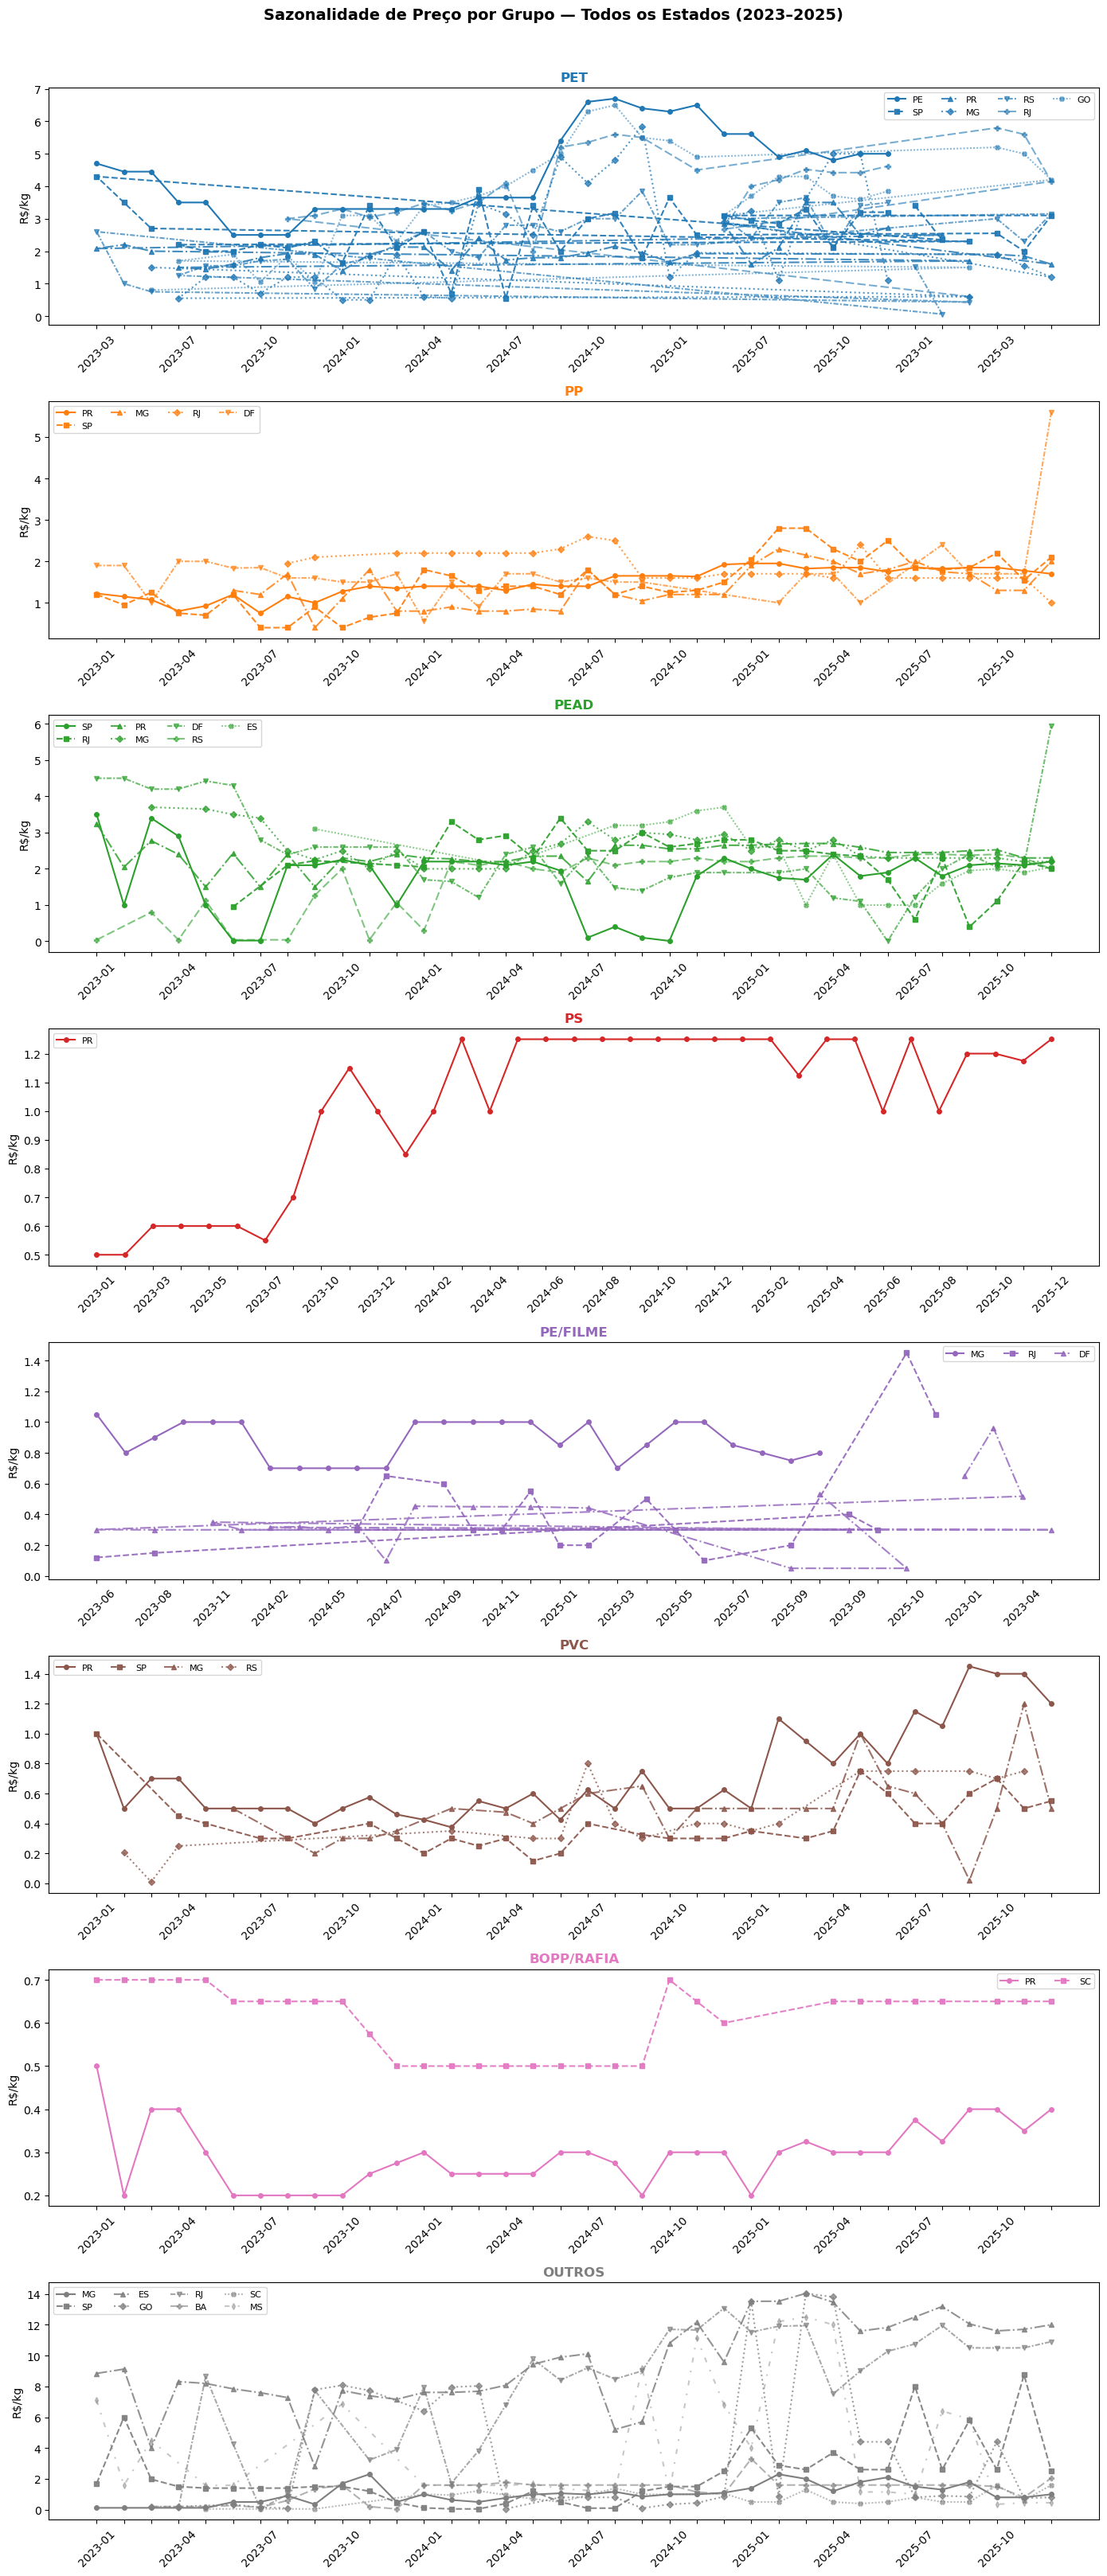

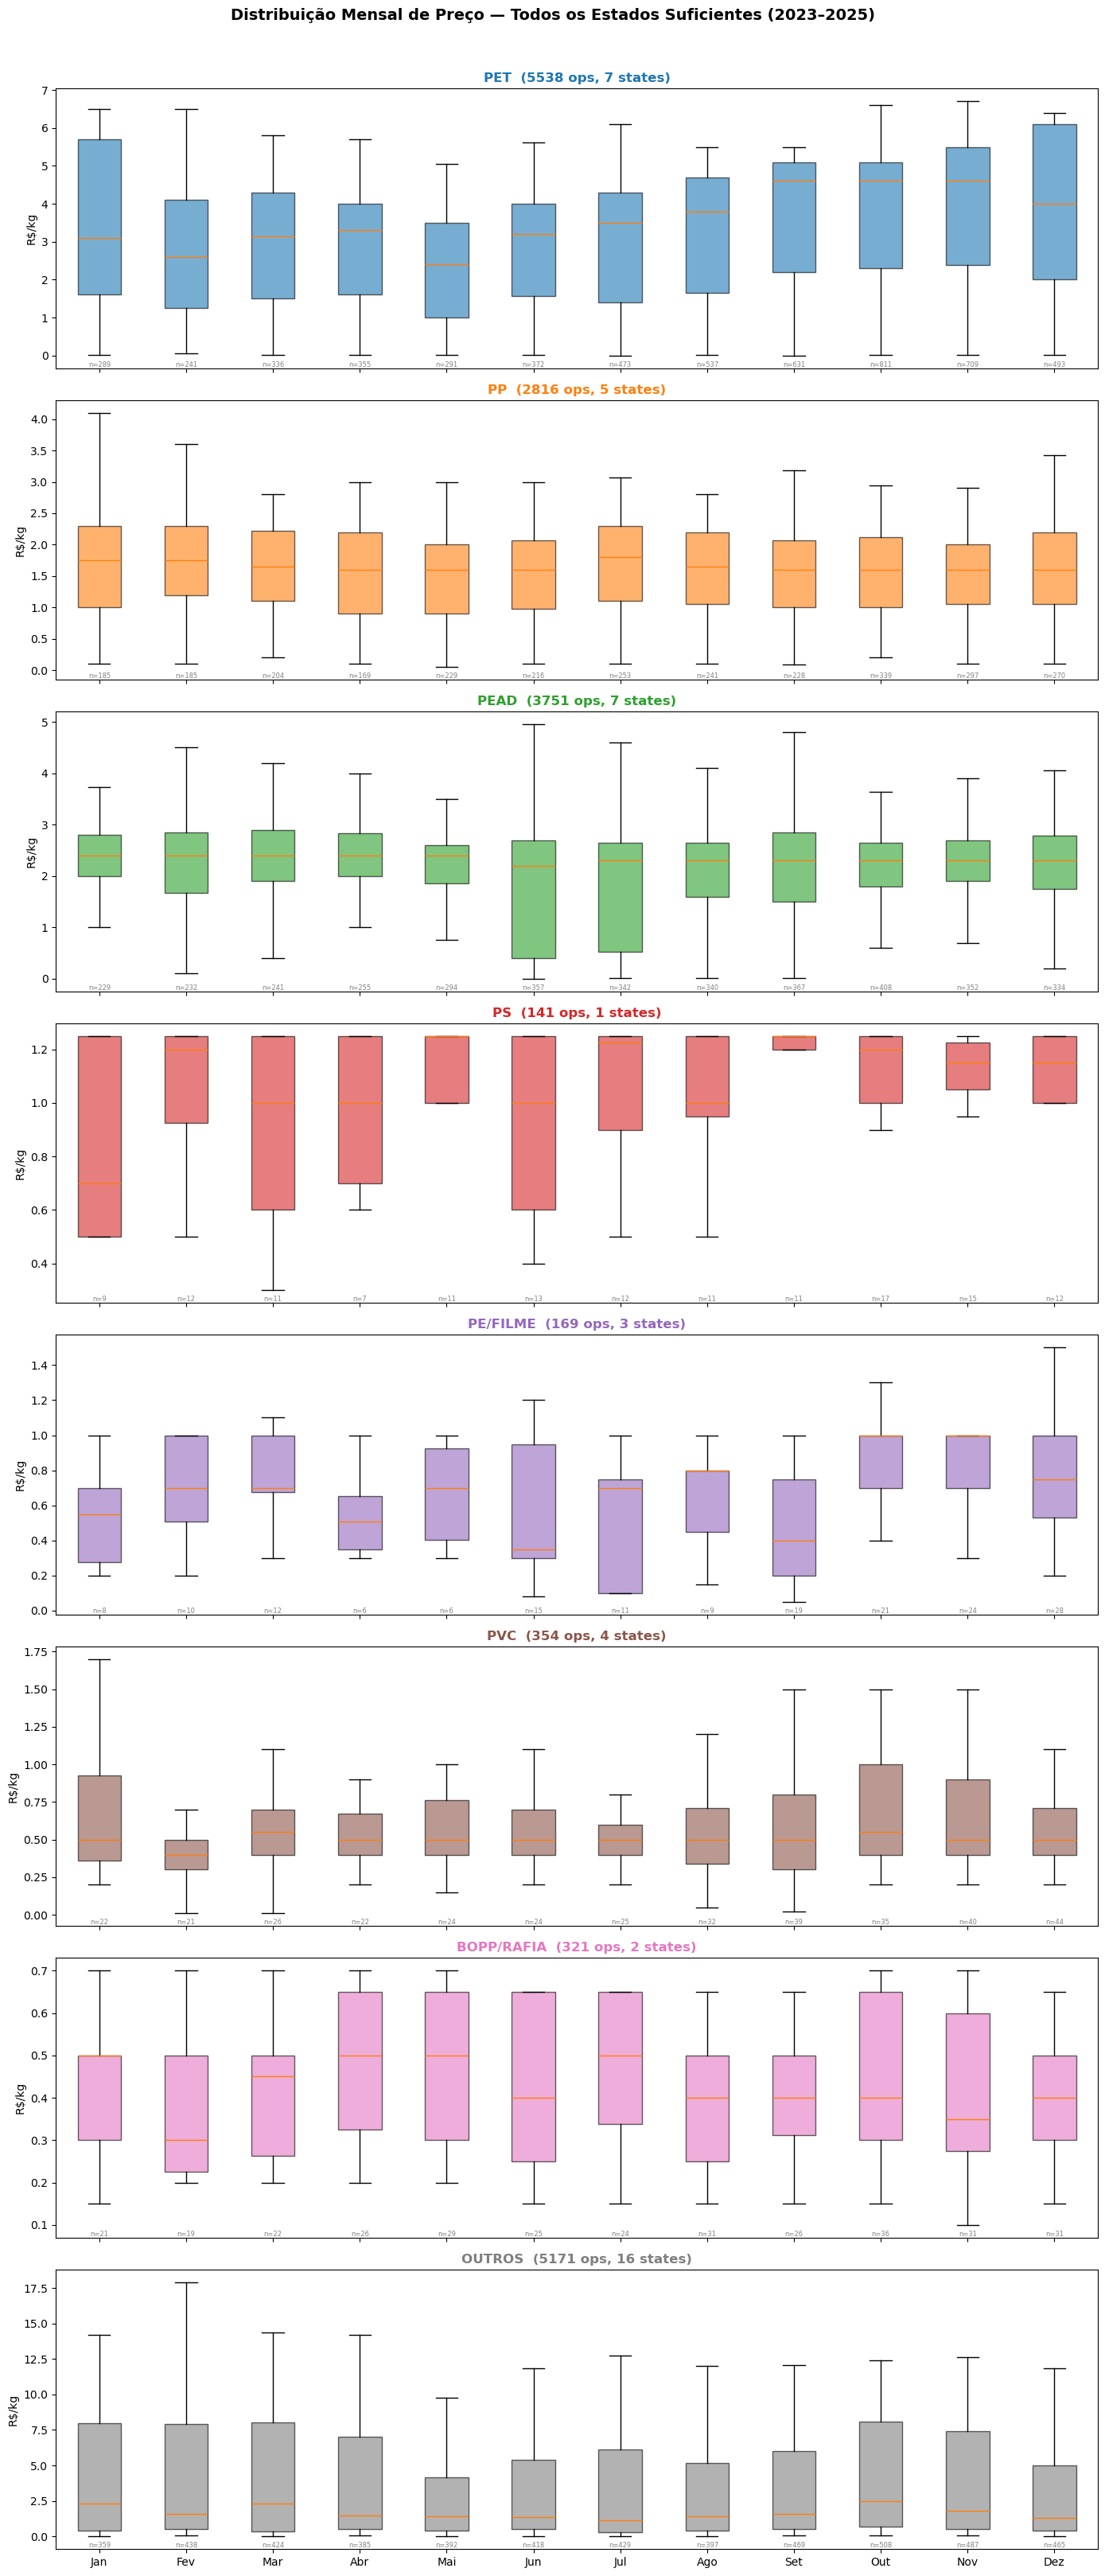

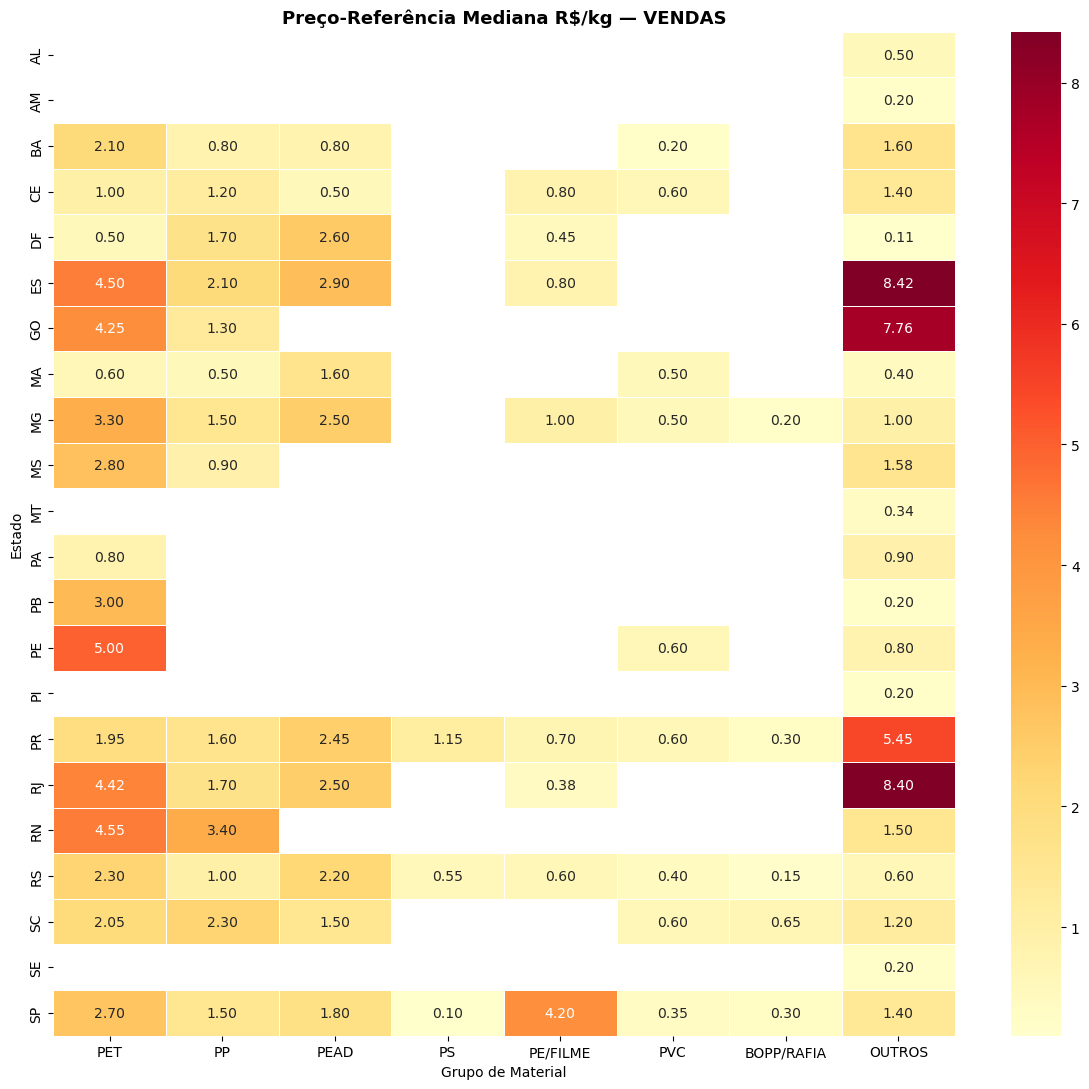

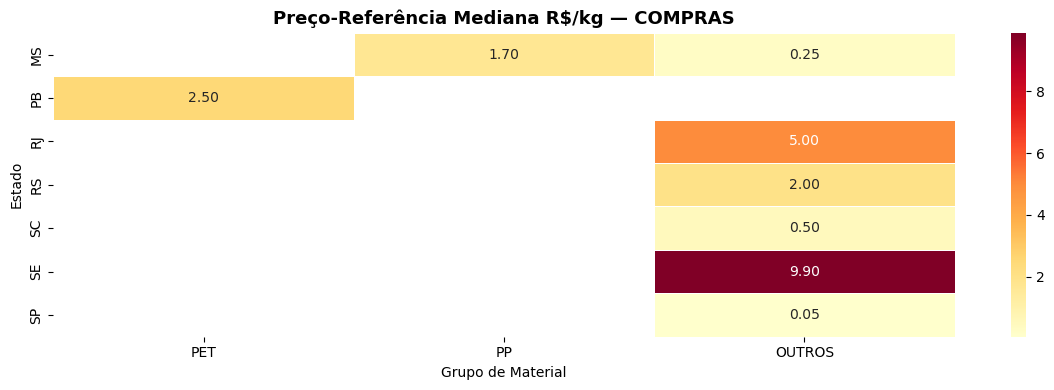

In [41]:
# === Seasonality: price (R$/kg) per material_group — ALL states ===
# Threshold: avg ≥ 1 row per month per sub-product in that (group, state) combo.

price_col = "unitpricekg_product"
df_season = df_matched.dropna(subset=[price_col]).copy()
df_season = df_season[df_season[price_col] > 0]

TOTAL_MONTHS = 36  # 2023-01 to 2025-12

# --- Data sufficiency: 1 row / month / sub-product ---
sufficiency = (
    df_season.groupby(["material_group", "emitterstateuf"])
    .apply(lambda g: pd.Series({
        "n_rows": len(g),
        "n_sub": g["estoque_product"].nunique(),
        "avg_per_month_sub": len(g) / (TOTAL_MONTHS * max(g["estoque_product"].nunique(), 1)),
    }))
    .reset_index()
)
good_combos = sufficiency[sufficiency["avg_per_month_sub"] >= 1.0]
print(f"Rows with valid price: {len(df_season)}")
print(f"\nData sufficiency (≥1 row/month/sub-product):")
display(good_combos.sort_values(["material_group", "emitterstateuf"]))

active_groups = [g for g in groups_sorted if g in good_combos["material_group"].unique()]
print(f"\nGroups with ≥1 sufficient state: {active_groups}")

# --- Monthly median ---
monthly_price = (
    df_season.groupby(["material_group", "emitterstateuf", "year", "month"])[price_col]
    .median().reset_index(name="median_price")
)

# --- Line styles for top states ---
LINE_STYLES = ["-", "--", "-.", ":", (0,(3,1,1,1)), (0,(5,2)), (0,(1,1)), (0,(3,5,1,5))]
STATE_MARKERS = ["o", "s", "^", "D", "v", "P", "X", "d"]

# === CHART 1: Median price over time per group ===
fig, axes = plt.subplots(len(active_groups), 1,
                         figsize=(14, 4 * len(active_groups)), sharex=False)
if len(active_groups) == 1:
    axes = [axes]

for ax, grp in zip(axes, active_groups):
    grp_states = good_combos[good_combos["material_group"] == grp]["emitterstateuf"].tolist()
    # rank by number of rows
    state_order = (
        df_season[(df_season["material_group"] == grp) & (df_season["emitterstateuf"].isin(grp_states))]
        .groupby("emitterstateuf").size().sort_values(ascending=False).index.tolist()[:8]
    )
    for j, state in enumerate(state_order):
        subset = monthly_price[
            (monthly_price["material_group"] == grp) & (monthly_price["emitterstateuf"] == state)
        ].sort_values(["year", "month"])
        if len(subset) == 0:
            continue
        x_labels = [f"{int(r.year)}-{int(r.month):02d}" for _, r in subset.iterrows()]
        ls = LINE_STYLES[j % len(LINE_STYLES)]
        mk = STATE_MARKERS[j % len(STATE_MARKERS)]
        ax.plot(x_labels, subset["median_price"], marker=mk, markersize=4,
                linewidth=1.5, label=state, linestyle=ls,
                color=GROUP_COLORS[grp], alpha=max(0.4, 1 - j * 0.08))
    ax.set_title(grp, fontsize=12, fontweight="bold", color=GROUP_COLORS[grp])
    ax.set_ylabel("R$/kg")
    ax.legend(fontsize=8, ncol=min(len(state_order), 4))
    ax.tick_params(axis="x", rotation=45)
    step = max(1, len(ax.get_xticklabels()) // 12)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % step != 0:
            label.set_visible(False)

plt.suptitle("Sazonalidade de Preço por Grupo — Todos os Estados (2023–2025)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# === CHART 2: Box plots by month (all sufficient states combined) ===
from matplotlib.patches import Patch

fig, axes = plt.subplots(len(active_groups), 1,
                         figsize=(14, 4 * len(active_groups)), sharex=True)
if len(active_groups) == 1:
    axes = [axes]

for ax, grp in zip(axes, active_groups):
    grp_states = good_combos[good_combos["material_group"] == grp]["emitterstateuf"].tolist()
    grp_data = df_season[
        (df_season["material_group"] == grp) & (df_season["emitterstateuf"].isin(grp_states))
    ]
    monthly_groups = [grp_data[grp_data["month"] == m][price_col].values for m in range(1, 13)]
    bp = ax.boxplot(monthly_groups, positions=range(1, 13), widths=0.5,
                    patch_artist=True, showfliers=False)
    for patch in bp["boxes"]:
        patch.set_facecolor(GROUP_COLORS[grp])
        patch.set_alpha(0.6)
    # annotate n= per month
    for m in range(1, 13):
        n = len(monthly_groups[m - 1])
        ax.annotate(f"n={n}", xy=(m, ax.get_ylim()[0]), fontsize=6, ha="center", va="bottom", color="gray")
    ax.set_title(f"{grp}  ({len(grp_data)} ops, {len(grp_states)} states)", fontsize=12,
                 fontweight="bold", color=GROUP_COLORS[grp])
    ax.set_ylabel("R$/kg")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
                         "Jul", "Ago", "Set", "Out", "Nov", "Dez"])

plt.suptitle("Distribuição Mensal de Preço — Todos os Estados Suficientes (2023–2025)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# === CHART 3: Price reference heatmap (median R$/kg by group x state) ===
for side_label, side_cats in [("VENDAS", venda_cats), ("COMPRAS", compra_cats)]:
    side_data = df_season[df_season["natop_category"].isin(side_cats)]
    if len(side_data) == 0:
        continue
    ref = (
        side_data.groupby(["material_group", "emitterstateuf"])[price_col]
        .agg(["median", "count"]).reset_index()
    )
    ref = ref[ref["count"] >= 10]  # need at least 10 data points
    pivot = ref.pivot(index="emitterstateuf", columns="material_group", values="median")
    pivot = pivot[[g for g in groups_sorted if g in pivot.columns]]
    if pivot.empty:
        continue
    fig, ax = plt.subplots(figsize=(12, max(4, len(pivot) * 0.5)))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax, linewidths=0.5)
    ax.set_title(f"Preço-Referência Mediana R$/kg — {side_label}", fontsize=13, fontweight="bold")
    ax.set_ylabel("Estado")
    ax.set_xlabel("Grupo de Material")
    plt.tight_layout()
    plt.show()